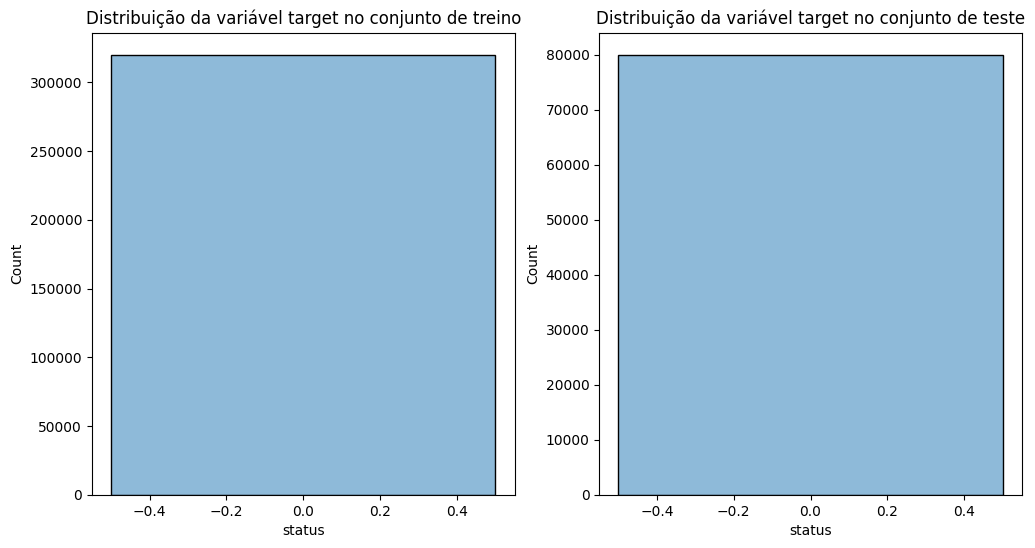

Mean Squared Error: 0.0


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho para os dados Silver
silver_path = '../data/silver/nafld_merged.parquet'

# Leitura do arquivo Parquet
df = pd.read_parquet(silver_path, engine='pyarrow')

# Remover colunas não numéricas e valores ausentes
df = df.drop(columns=['Unnamed: 0', 'id', 'test']).dropna()

# Selecionar colunas com correlação significativa
columns_to_keep = ['case.id', 'bmi', 'age']
X = df[columns_to_keep]
y = df['status']

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar a distribuição dos dados
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(y_train, kde=True)
plt.title('Distribuição da variável target no conjunto de treino')

plt.subplot(1, 2, 2)
sns.histplot(y_test, kde=True)
plt.title('Distribuição da variável target no conjunto de teste')
plt.show()

# Treinamento do modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')